<a href="https://colab.research.google.com/github/Sophiagazula/Fill_Rate_Prediction/blob/main/Fill_Rate_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import pandas as pd

df = pd.read_csv('messy_forecasting_dataset.csv')


#df = df.dropna()

df['date'] = pd.to_datetime(df['date'],errors='coerce')
df['demand_qty'] = df['demand_qty'].fillna(0)
df['fulfilled_qty'] = df['fulfilled_qty'].fillna(0)
df['demand_qty'] = df['demand_qty'].astype(int)
df['fulfilled_qty'] = df['fulfilled_qty'].astype(int)
df.head()

#drop duplicates
df = df.drop_duplicates()

df.head(10)




,date,warehouse_id,sku_id,demand_qty,fulfilled_qty
0,2025-01-01,W1,SKU1,69,52
1,2025-01-02,W1,SKU1,84,60
2,2025-01-03,W1,SKU1,83,76
3,2025-01-04,W1,SKU1,0,0
4,2025-01-05,W1,SKU1,0,0
5,2025-01-06,W1,SKU1,75,59
6,2025-01-07,W1,SKU1,0,0
7,2025-01-08,W1,SKU1,90,79
8,2025-01-09,W1,SKU1,76,62
9,2025-01-10,W1,SKU1,73,61


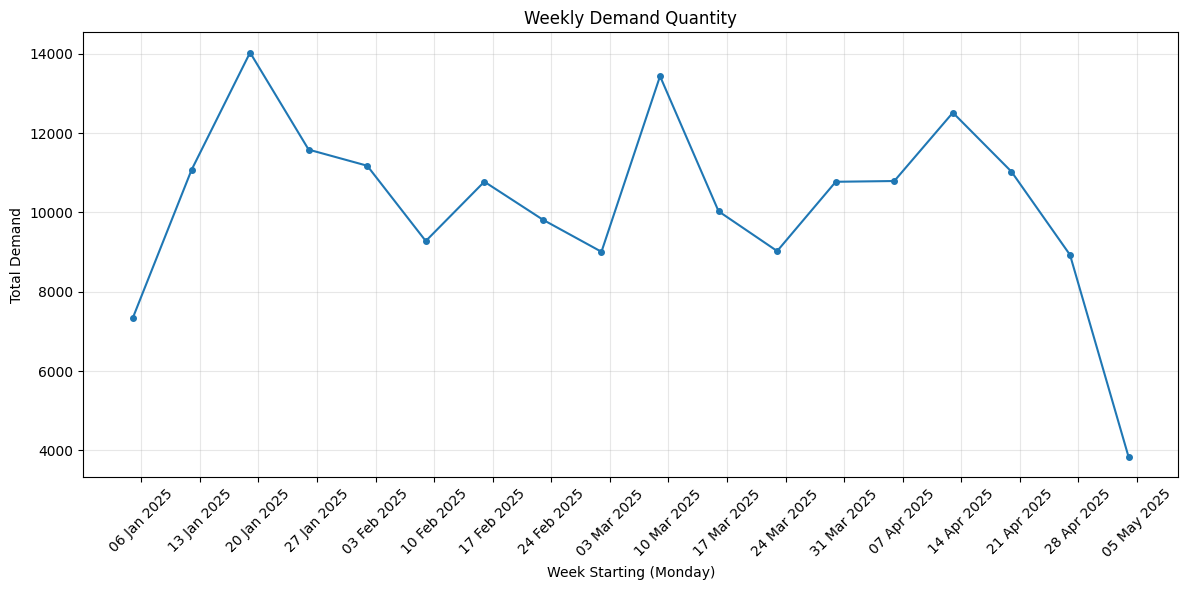

In [26]:
#matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. Resample data to Weekly ('W') and sum the demand
# This groups data into 7-day chunks ending on Sundays
df_weekly = df.set_index('date')['demand_qty'].resample('W').sum().reset_index()

# 2. Plot the aggregated weekly data
plt.figure(figsize=(12, 6))
plt.plot(df_weekly['date'], df_weekly['demand_qty'], marker='o', linestyle='-', markersize=4)

# 3. Format the X-axis for weekly ticks
# We use WeekdayLocator to mark every Monday (MO)
# 'interval=1' shows every week; change to 2 if the labels get too crowded
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))

plt.xticks(rotation=45)
plt.title('Weekly Demand Quantity')
plt.xlabel('Week Starting (Monday)')
plt.ylabel('Total Demand')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [81]:
# create KPI Calculation for fill rate
df['fill_rate'] = (df['fulfilled_qty'] / df['demand_qty']) * 100
df['fill_rate'] = df['fill_rate'].fillna(0)

df_filtered = df[(df['sku_id'] == 'SKU2') & (df['warehouse_id'] == 'W1')]

df_filtered.head()

,date,warehouse_id,sku_id,demand_qty,fulfilled_qty,fill_rate
120,2025-01-01,W1,SKU2,45,37,82.222222
121,2025-01-02,W1,SKU2,40,36,90.000000
122,2025-01-03,W1,SKU2,35,35,100.000000
123,2025-01-04,W1,SKU2,40,38,95.000000
124,2025-01-05,W1,SKU2,40,29,72.500000


In [60]:
# group fillrate at daily level
daily = df.groupby(['date','sku_id'])['fill_rate'].mean().reset_index()
daily.head()

,date,sku_id,fill_rate
0,2025-01-01,SKU1,79.854131
1,2025-01-01,SKU2,83.175986
2,2025-01-01,SKU3,82.220263
3,2025-01-01,SKU4,64.476739
4,2025-01-01,SKU5,86.163958


In [65]:
#Calculate datenum and day of week
import numpy as np

# Apply the mapping to the daily dataframe
daily['day_num'] = np.arange(len(daily))
daily['day_of_week'] = daily['date'].dt.dayofweek

daily.head()

,date,sku_id,fill_rate,date_num,day_num,day_of_week
0,2025-01-01,SKU1,79.854131,0,0,2
1,2025-01-01,SKU2,83.175986,0,1,2
2,2025-01-01,SKU3,82.220263,0,2,2
3,2025-01-01,SKU4,64.476739,0,3,2
4,2025-01-01,SKU5,86.163958,0,4,2


In [66]:
#create simple regression
from sklearn.linear_model import LinearRegression

# 1. Convert sku_id into numeric columns (One-Hot Encoding)
# This allows the model to learn a different 'baseline' fill rate for each SKU
X = pd.get_dummies(daily[['date_num', 'sku_id']], columns=['sku_id'], drop_first=True)
y = daily['fill_rate']

# 2. Train the model
model = LinearRegression()
model.fit(X, y)

print("Model trained successfully with SKU features!")


Model trained successfully with SKU features!


In [70]:
#create future dates
skus = daily['sku_id'].unique()
future_dates = pd.date_range(start=daily['date'].max(), periods=42)

# Create a 'grid' of every SKU for every future date
from itertools import product
predict_df = pd.DataFrame(list(product(future_dates, skus)), columns=['date', 'sku_id'])

# 2. Add the date_num (continuing from where the training data left off)
last_num = daily['date_num'].max()
date_map = {d: i + last_num + 1 for i, d in enumerate(future_dates)}
predict_df['date_num'] = predict_df['date'].map(date_map)

# 3. Prepare features (must match the training X exactly)
X_future = pd.get_dummies(predict_df[['date_num', 'sku_id']], columns=['sku_id'], drop_first=True)

# 4. Predict
predict_df['forecast_fill_rate'] = model.predict(X_future)

predict_df.head(10)



,date,sku_id,date_num,forecast_fill_rate
0,2025-04-30,SKU1,120,75.520737
1,2025-04-30,SKU2,120,76.021183
2,2025-04-30,SKU3,120,74.896761
3,2025-04-30,SKU4,120,76.485195
4,2025-04-30,SKU5,120,76.197760
5,2025-05-01,SKU1,121,75.533589
6,2025-05-01,SKU2,121,76.034034
7,2025-05-01,SKU3,121,74.909612
8,2025-05-01,SKU4,121,76.498047
9,2025-05-01,SKU5,121,76.210611


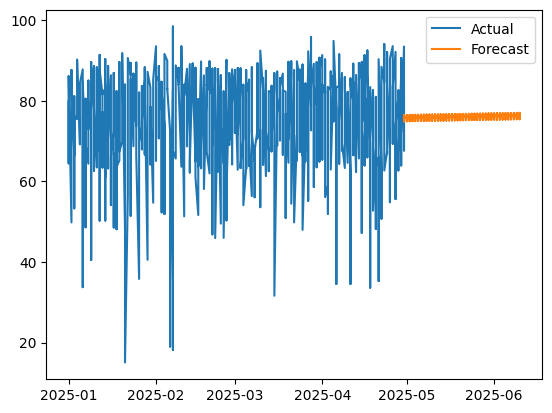

In [72]:
#view it on plot
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.plot(daily['date'], daily['fill_rate'], label='Actual')
plt.plot(predict_df['date'], predict_df['forecast_fill_rate'], label='Forecast')
plt.legend()
plt.show()